In [259]:
import numpy as np
import pandas as pd

In [190]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [191]:
df.dtypes

model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [192]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')

*Preparing the dataset*

In [193]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [194]:
print(df.head())

   engine_displacement  horsepower  vehicle_weight  model_year  \
0                 2180       243.0            3870        2006   
1                 2390       272.0            4210        2008   
2                 2320       267.0            4240        1996   
3                 2130       258.0            4490        1989   
4                 2580       304.0            4510        1994   

   fuel_efficiency_mpg  
0                 31.9  
1                 31.3  
2                 27.5  
3                 28.5  
4                 31.0  


*EDA*

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

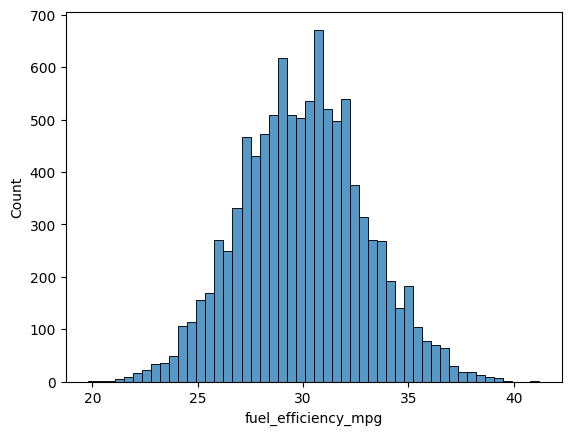

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df.fuel_efficiency_mpg, bins=50)

**Question 1**

There's one column with missing values. What is it?

In [196]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Question 2**

What's the median (50% percentile) for variable 'horsepower'?

In [197]:
median_hp = df['horsepower'].median()
print("Median hp:", median_hp)

Median hp: 254.0


*Prepare and split the dataset*

In [198]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [199]:
n

10000

In [200]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [201]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [202]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [203]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [204]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [206]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [207]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [208]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

**Question 3**

fill missing values with 0 

In [209]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [210]:
df_train[base]

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [211]:
df_train[base].isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [212]:
df_fill_zero_train = df_train[base].copy()
df_fill_zero_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [213]:
df_fill_zero_val = df_val[base].copy()
df_fill_zero_val

,engine_displacement,horsepower,vehicle_weight,model_year
0,2240,265.0,3990,2004
1,2390,259.0,4770,2019
2,2360,265.0,4320,2018
3,2430,279.0,4430,2008
4,2220,249.0,4030,1999
...,...,...,...,...
1995,1980,229.0,4140,2020
1996,2590,263.0,4630,1989
1997,2390,264.0,4550,2017
1998,2330,244.0,4440,2014


In [214]:
df_fill_zero_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [215]:
df_fill_zero_train['horsepower'] = df_fill_zero_train['horsepower'].fillna(0)

In [216]:
df_fill_zero_train.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [217]:
df_fill_zero_val.isnull().sum()

engine_displacement      0
horsepower             176
vehicle_weight           0
model_year               0
dtype: int64

In [218]:
df_fill_zero_val['horsepower'] = df_fill_zero_val['horsepower'].fillna(0)

In [219]:
df_fill_zero_val.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

*train a linear regression model*

In [220]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [221]:
X_train = df_fill_zero_train.values
X_val = df_fill_zero_val.values
w0, w = train_linear_regression(X_train, y_train)
y_pred_zero = w0 + X_val.dot(w)

In [222]:
train_linear_regression(X_train, y_train)
y_pred_zero = w0 + X_val.dot(w)
y_pred_zero

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

<Axes: ylabel='Count'>

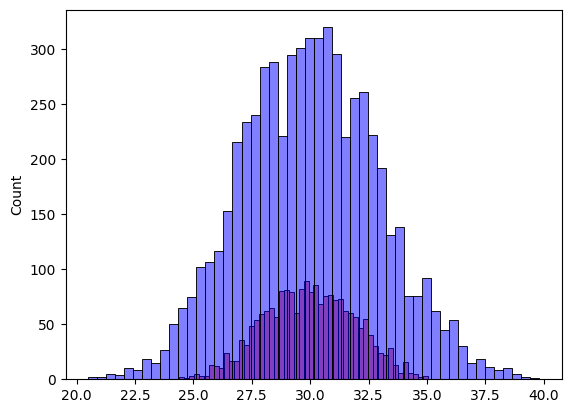

In [223]:
sns.histplot(y_pred_zero, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [224]:
def rmse(y_val, y_pred_zero):
    se = (y_val - y_pred_zero) ** 2
    mse = se.mean()
    return np.sqrt(mse)
    
rmse(y_val, y_pred_zero)

np.float64(2.20529319475341)

In [225]:
score = rmse(y_val, y_pred_zero)
print(round(score, 2))

2.21


*Fill missing values with mean*

In [226]:
df_fill_mean_train = df_train[base].copy()
df_fill_mean_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [227]:
df_fill_mean_val = df_val[base].copy()
df_fill_mean_val

,engine_displacement,horsepower,vehicle_weight,model_year
0,2240,265.0,3990,2004
1,2390,259.0,4770,2019
2,2360,265.0,4320,2018
3,2430,279.0,4430,2008
4,2220,249.0,4030,1999
...,...,...,...,...
1995,1980,229.0,4140,2020
1996,2590,263.0,4630,1989
1997,2390,264.0,4550,2017
1998,2330,244.0,4440,2014


In [228]:
mean_hp = df_fill_mean_train['horsepower'].mean()

df_fill_mean_train['horsepower'] = df_fill_mean_train['horsepower'].fillna(mean_hp)

In [229]:
df_fill_mean_train['horsepower'].isna().sum()

np.int64(0)

In [230]:
mean_hp = df_fill_mean_val['horsepower'].mean()

df_fill_mean_val['horsepower'] = df_fill_mean_val['horsepower'].fillna(mean_hp)

In [231]:
df_fill_mean_val['horsepower'].isna().sum()

np.int64(0)

In [232]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [233]:
X_train = df_fill_mean_train.values
X_val = df_fill_mean_val.values
w0, w = train_linear_regression(X_train, y_train)
y_pred_mean = w0 + X_val.dot(w)

In [234]:
train_linear_regression(X_train, y_train)
y_pred_mean = w0 + X_val.dot(w)
y_pred_mean

array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
       30.85701236, 31.55313717], shape=(2000,))

In [235]:
def rmse(y_val, y_pred_mean):
    se = (y_val - y_pred_mean) ** 2
    mse = se.mean()
    return np.sqrt(mse)
    
rmse(y_val, y_pred_mean)
score = rmse(y_val, y_pred_mean)
print(round(score, 2))

2.2


**Question 4**

In [236]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [237]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train_zero = df_fill_zero_train.values
    X_val_zero = df_fill_zero_val.values
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)

    y_pred_zero = w0 + X_val_zero.dot(w)
    score = rmse(y_val, y_pred_zero)
    
    print(r, w0, round(score, 4))

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


**Question 5**

In [249]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [250]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [252]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [260]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

rmse_scores = []

for seed in seeds:

    # Split with current seed
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    # Fill missing values with 0
    X_train = df_train[base].fillna(0).values
    X_val = df_val[base].fillna(0).values

    # Target
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    # Train linear regression
    w0, w = train_linear_regression(X_train, y_train)

    # Prediction
    y_pred = w0 + X_val.dot(w)

    # RMSE
    score = rmse(y_val, y_pred)

    rmse_scores.append(score)

    print(seed, score)


0 2.239204143046126
1 2.2021128210838845
2 2.1634197787530947
3 2.2043588768539224
4 2.2018800943311554
5 2.2457851509085134
6 2.2697212079524043
7 2.190794599933443
8 2.216611201686444
9 2.2070365928178957


In [258]:
# Standard deviation
std = np.std(rmse_scores)

print("RMSE scores:", rmse_scores)
print("Standard deviation:", std)
print("Rounded:", round(std, 3))

RMSE scores: [np.float64(2.239204143046126), np.float64(2.2021128210838845), np.float64(2.1634197787530947), np.float64(2.2043588768539224), np.float64(2.2018800943311554), np.float64(2.2457851509085134), np.float64(2.2697212079524043), np.float64(2.190794599933443), np.float64(2.216611201686444), np.float64(2.2070365928178957)]
Standard deviation: 0.028781274078191175
Rounded: 0.029


**Question 6**

In [185]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'
df = df.dropna(subset=[target])

In [187]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Regularized linear regression function
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

# RMSE function
def rmse(y_val, y_pred_zero):
    se = (y_val - y_pred_zero) ** 2
    mse = se.mean()
    return np.sqrt(mse)
    
rmse(y_val, y_pred_zero)

# Prepare feature matrix
def prepare_X(df):
    return df[base].fillna(0).values

# Split using seed 9
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# Combine train + validation
df_full_train = pd.concat([df_train, df_val])

X_train = prepare_X(df_full_train)
y_train = df_full_train[target].values

X_test = prepare_X(df_test)
y_test = df_test[target].values

# Train model with r=0.001
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
y_pred = w0 + X_test.dot(w)

# Compute RMSE
score = round(rmse(y_test, y_pred), 3)
print("RMSE on test dataset:", score)

RMSE on test dataset: 2.236
